# Exploratory Data Analysis (EDA)
## Dataset: POS_CASH_balance

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the `POS_CASH_balance` dataset from the Home Credit risk modeling case. This table contains monthly balance snapshots of previous POS and cash loans held by applicants at Home Credit, providing behavioral signals on installment payment history for predicting loan default.

---

## 🎯 Objectives
- Understand the structure and characteristics of the `POS_CASH_balance` dataset
- Identify data quality issues (missing values, outliers, inconsistencies)
- Analyze the distribution of key variables
- Explore relationships between aggregated features and the target variable (loan default)
- Generate aggregated features ready for merging into the main table

---

## 🔍 Analysis Scope
The analysis includes:
- Missing Value Analysis
- Univariate analysis (distribution of individual variables)
- Bivariate analysis (relationships between features)
- Aggregation strategy (POS_CASH_balance to SK_ID_CURR)
- Bivariate analysis of aggregated features vs TARGET
- Initial business-driven interpretation of POS and cash loan balance behavior

---

## 🧠 Key Questions
- What is the monthly payment behavior profile of applicants on previous POS and cash loans?
- How do installment completion and overdue patterns relate to default behavior?
- What aggregated signals from POS_CASH_balance are most predictive of default?
- Are there patterns in contract status that differentiate defaulters?

---

## 🛠 Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

## 📊 Output
The output of this EDA will serve as:
- Aggregated POS_CASH_balance features ready for merging into the main modeling table
- Business insights on installment payment behavior
- Input for feature selection and credit scoring models

# Importing Library

In [1]:
# Installation Library
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Hide Warning
import warnings
warnings.filterwarnings('ignore')

# Importing Library
import pandas as pd
# Setting Pandas Row Display Max
pd.set_option('display.max_rows', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Importing Dataset

In [3]:
# Dataset POS_CASH_balance
pos_cash_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\POS_CASH_balance.csv'
df_pos = pd.read_csv(pos_cash_path)

# Dataset application_train (for bivariate aggregated features vs TARGET)
application_train_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\application_train.csv'
df_app_train = pd.read_csv(application_train_path)

# 1. About Dataset

The dataset consists of **10,001,358 observations** and **8 features**, representing monthly balance snapshots of previous POS and cash loans held by applicants at Home Credit. Each row corresponds to one month of history for a given previous loan, linked to an applicant via `SK_ID_CURR` and to a specific previous loan via `SK_ID_PREV`.

The features can be grouped into several categories:
- **Key identifiers**: `SK_ID_PREV` (link to previous_application) and `SK_ID_CURR` (link to main table)
- **Numerical features**: `MONTHS_BALANCE` (relative month), `CNT_INSTALMENT` (total installments), `CNT_INSTALMENT_FUTURE` (remaining installments), `SK_DPD` (days past due), `SK_DPD_DEF` (days past due defined)
- **Categorical feature**: `NAME_CONTRACT_STATUS`, indicating the contract status for that month

In [4]:
df_pos.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int64  
 1   SK_ID_CURR             int64  
 2   MONTHS_BALANCE         int64  
 3   CNT_INSTALMENT         float64
 4   CNT_INSTALMENT_FUTURE  float64
 5   NAME_CONTRACT_STATUS   str    
 6   SK_DPD                 int64  
 7   SK_DPD_DEF             int64  
dtypes: float64(2), int64(5), str(1)
memory usage: 610.4 MB


# 2. Contract Status Distribution

The contract status distribution shows the monthly status of previous POS and cash loans held by applicants at Home Credit. Understanding the proportion of active, completed, and delinquent contracts provides an initial signal of the payment behavior profile across applicants.

- Total Active: 9,151,119 (~91.50%)
- Total Completed: 744,883 (~7.45%)
- Total Signed: 87,260 (~0.87%)
- Total Demand: 7,065 (~0.07%)
- Total Returned to the store: 5,461 (~0.05%)
- Total Approved: 4,917 (~0.05%)
- Total Amortized debt: 636 (~0.01%)
- Total Canceled: 15 (~0.00%)
- Total XNA: 2 (~0.00%)

The vast majority of monthly records are **Active (~91.50%)**, reflecting that most observations represent ongoing loan months. **Completed (~7.45%)** represents fully settled loans. `Demand`, `Returned to the store`, and `Amortized debt` are rare but may carry risk signal worth preserving during aggregation. `Canceled` and `XNA` are negligible with only 17 combined records.

In [5]:
# Contract status value counts
print(df_pos['NAME_CONTRACT_STATUS'].value_counts())
print(f"\nContract Status Distribution (%):")
print((df_pos['NAME_CONTRACT_STATUS'].value_counts() / len(df_pos) * 100).round(2))

NAME_CONTRACT_STATUS
Active                   9151119
Completed                 744883
Signed                     87260
Demand                      7065
Returned to the store       5461
Approved                    4917
Amortized debt               636
Canceled                      15
XNA                            2
Name: count, dtype: int64

Contract Status Distribution (%):
NAME_CONTRACT_STATUS
Active                   91.50
Completed                 7.45
Signed                    0.87
Demand                    0.07
Returned to the store     0.05
Approved                  0.05
Amortized debt            0.01
Canceled                  0.00
XNA                       0.00
Name: count, dtype: float64


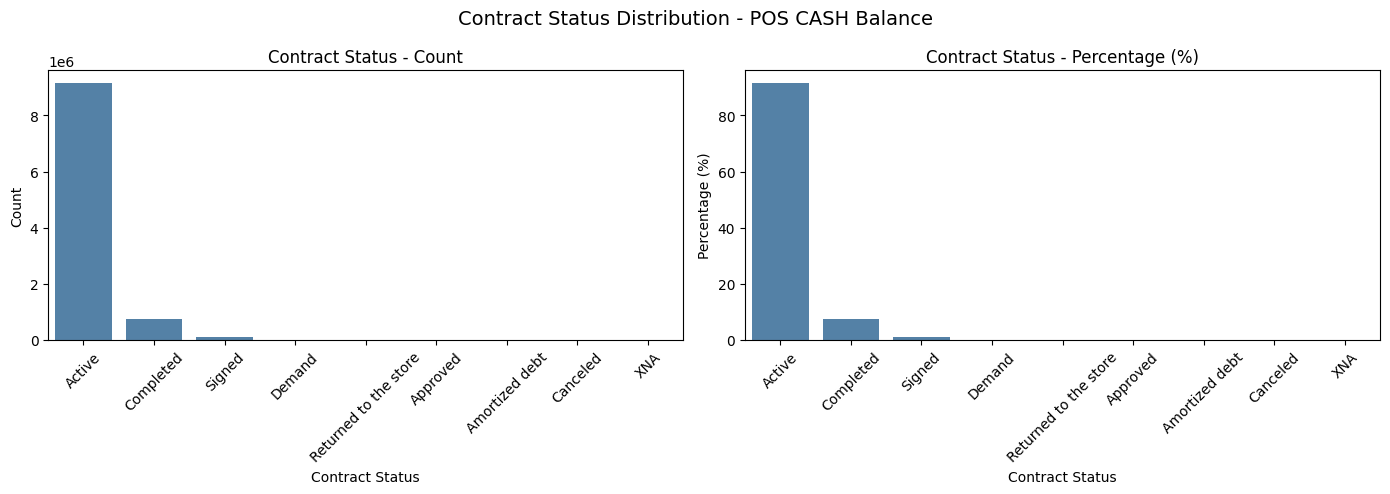

In [6]:
# Bar plot - contract status distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
contract_status_counts = df_pos['NAME_CONTRACT_STATUS'].value_counts()
sns.barplot(x=contract_status_counts.index, y=contract_status_counts.values, ax=axes[0], color='steelblue')
axes[0].set_title('Contract Status - Count')
axes[0].set_xlabel('Contract Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Percentage plot
contract_status_pct = df_pos['NAME_CONTRACT_STATUS'].value_counts(normalize=True) * 100
sns.barplot(x=contract_status_pct.index, y=contract_status_pct.values, ax=axes[1], color='steelblue')
axes[1].set_title('Contract Status - Percentage (%)')
axes[1].set_xlabel('Contract Status')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Contract Status Distribution - POS CASH Balance', fontsize=14)
plt.tight_layout()
plt.show()

# 3. Missing Value Analysis

The missing value analysis is conducted to assess data quality and identify potential information contained within missing data.

The approach includes:
- **Measuring** the count and percentage of missing values for each feature
- **Evaluating** the likely cause of missingness based on domain context
- **Defining** a handling strategy for each missing feature

The results of this analysis serve as recommendations for the data handling stage, including imputing values and deciding whether missingness itself carries meaningful signal.

In [7]:
# Missing value count and percentage
missing_pos = pd.DataFrame({
    'Missing Count': df_pos.isnull().sum(),
    'Missing (%)': (df_pos.isnull().sum() / len(df_pos) * 100).round(2)
})
missing_pos = missing_pos[missing_pos['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)

if missing_pos.empty:
    print("No missing values found in POS_CASH_balance.")
else:
    print(missing_pos)

                       Missing Count  Missing (%)
CNT_INSTALMENT                 26071         0.26
CNT_INSTALMENT_FUTURE          26087         0.26


### Key Findings & Handling Strategy

The `POS_CASH_balance` dataset contains **2 features with missing values**, both of which are numerical with negligible missing rates.

Key observations:
- `CNT_INSTALMENT` (0.26%) and `CNT_INSTALMENT_FUTURE` (0.26%) have nearly identical missing counts, suggesting they are missing together for the same rows. This likely reflects records where installment schedule information was not captured.

**Handling Strategy:**
- `CNT_INSTALMENT`, `CNT_INSTALMENT_FUTURE`: impute with **median** per `NAME_CONTRACT_STATUS` group, as installment counts may vary meaningfully across contract status types.

# 4. Numerical Features Analysis

Numerical features in `POS_CASH_balance` are analyzed to understand their distributions, central tendencies, and relationships. This section covers both univariate and bivariate analysis before aggregation.

The approach includes:
- **Describing** each feature through summary statistics
- **Visualizing** distributions to detect skewness and anomalies
- **Detecting** outliers using boxplots
- **Examining** pairwise correlations between numerical features

## 4.1 Univariate Analysis

Univariate analysis examines each numerical feature independently to understand its distribution, central tendency, and spread. This serves as the foundation before exploring relationships between features.

The approach includes:
- **Describing** each feature through summary statistics (mean, median, std, min, max)
- **Identifying** potential anomalies, skewness, and extreme values

### 4.1.1 Statistical Descriptive

In [8]:
# Numerical features in POS_CASH_balance (exclude identifiers)
num_cols_pos = df_pos.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols_pos = [col for col in num_cols_pos if col not in ['SK_ID_PREV', 'SK_ID_CURR']]

# Statistical description
df_pos[num_cols_pos].describe().T

,count,mean,std,min,25%,50%,75%,max
MONTHS_BALANCE,10001358.0,-35.012588,26.066570,-96.0,-54.0,-28.0,-13.0,-1.0
CNT_INSTALMENT,9975287.0,17.089650,11.995056,1.0,10.0,12.0,24.0,92.0
CNT_INSTALMENT_FUTURE,9975271.0,10.483840,11.109058,0.0,3.0,7.0,14.0,85.0
SK_DPD,10001358.0,11.606928,132.714043,0.0,0.0,0.0,0.0,4231.0
SK_DPD_DEF,10001358.0,0.654468,32.762491,0.0,0.0,0.0,0.0,3595.0


##### Key Findings

**MONTHS_BALANCE (Negative Values by Design)**
`MONTHS_BALANCE` ranges from -96 to -1, negative by design representing months relative to application date. Median of -28 indicates the typical observation is approximately 28 months before application. No transformation needed in EDA.

**CNT_INSTALMENT and CNT_INSTALMENT_FUTURE**
`CNT_INSTALMENT` median of 12 with max of 92 reflects standard loan terms, consistent with discrete spikes seen in `previous_application` CNT_PAYMENT. `CNT_INSTALMENT_FUTURE` median of 7 indicates most loans are past halfway through their repayment schedule at the time of observation.

**Anomalies Detected**
- `SK_DPD` max = **4,231**, extreme outlier indicating severe days past due. Median of 0 confirms overdue events are rare but extreme when they occur.
- `SK_DPD_DEF` max = **3,595**, similarly extreme. Both DPD features require capping before aggregation.

**Skewed Distributions**
- `SK_DPD` and `SK_DPD_DEF` have median = 0 with extreme max values, heavily right-skewed. Most applicants have no overdue days but a small subset has severe delinquency.
- `CNT_INSTALMENT` mean 17 vs median 12, moderately right-skewed reflecting longer-term loans pulling the mean up.

**Features for Further Analysis**
- `SK_DPD` and `SK_DPD_DEF` to confirm outlier severity and distribution shape
- `CNT_INSTALMENT` and `CNT_INSTALMENT_FUTURE` to examine distribution of loan progress
- `MONTHS_BALANCE` to confirm distribution of observable history depth

---

### 4.1.2 Distribution Plot

Distribution plots are used to examine the shape of each numerical feature - whether it is normally distributed, right-skewed, or contains anomalies. Features with high skewness may require log transformation during preprocessing.

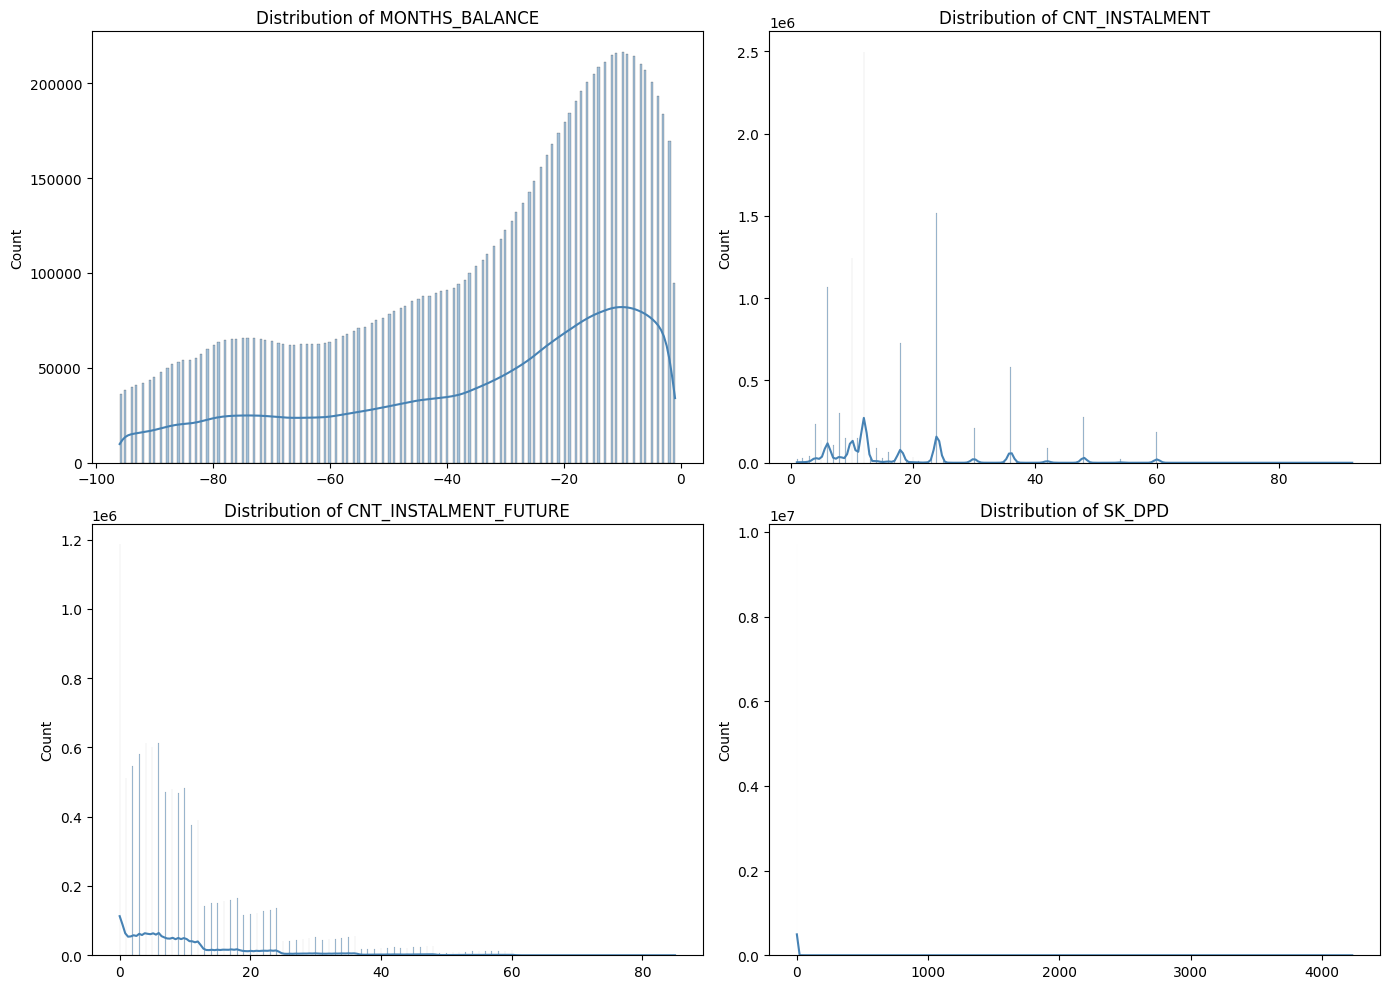

In [9]:
# Select key numerical features for distribution analysis
num_features_dist = [
    'MONTHS_BALANCE', 'CNT_INSTALMENT',
    'CNT_INSTALMENT_FUTURE', 'SK_DPD'
]

# Grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_features_dist):
    sns.histplot(df_pos[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

##### Key Findings

- `MONTHS_BALANCE` shows a right-skewed distribution concentrated near 0 (most recent months) with a gradual taper toward -96, consistent with accumulation of more recent monthly records across all active loans.
- `CNT_INSTALMENT` shows a discrete distribution with distinct spikes at standard loan terms (6, 12, 18, 24, 36 months), reflecting structured loan products. No anomalies detected.
- `CNT_INSTALMENT_FUTURE` is heavily concentrated near 0 with a rapid decline, indicating most observations are near the end of the repayment schedule. Consistent with the dataset being dominated by Active status records.
- `SK_DPD` is almost entirely at zero with an extremely long right tail extending to ~4,000, confirming overdue events are rare but severe when they occur. **Capping recommended.**

---

### 4.1.3 Outlier Detection

Boxplots are used to detect outliers in numerical features. Extreme values can distort model training and may require capping or domain-aware treatment before modeling.

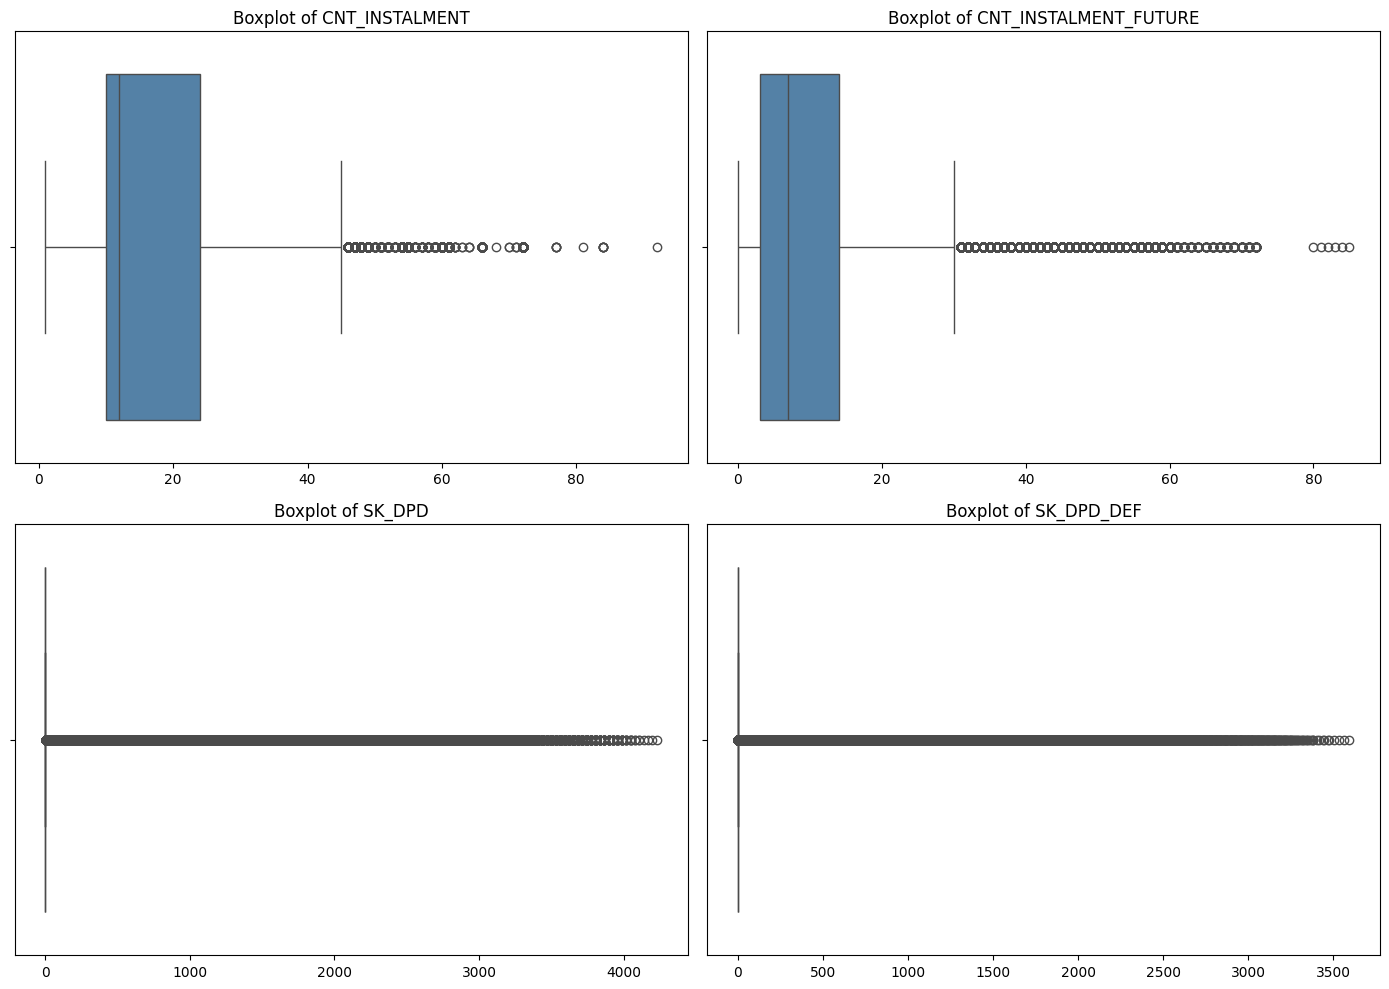

In [10]:
# Select key numerical features for outlier detection
outlier_features = [
    'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE',
    'SK_DPD', 'SK_DPD_DEF'
]

# Grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    sns.boxplot(x=df_pos[col].dropna(), ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()



##### Key Findings

- `CNT_INSTALMENT` shows moderate outliers above 45 months, reflecting longer-term loan products. Reasonable range, no special handling required.
- `CNT_INSTALMENT_FUTURE` shows sparse outliers above 40, consistent with loans early in their repayment schedule. No special handling required.
- `SK_DPD` shows extreme outliers extending to 4,231 with the entire IQR compressed at zero, **needs capping.**
- `SK_DPD_DEF` shows similar pattern with outliers extending to 3,595, **needs capping.**

All DPD features require outlier treatment before aggregation and modeling. Capping at 99th percentile is recommended.

---